# Customer Churn Prediction – Model Development

## Objective

The objective of this notebook is to develop machine-learning
classification models for predicting customer churn.

## Modeling Workflow

- Load the feature-engineered dataset
- Separate features and target
- Split the data into training and testing sets
- Identify numerical and categorical features
- Build a Scikit-learn preprocessing pipeline
- Train a Logistic Regression baseline
- Evaluate the baseline model
- Prepare the workflow for Random Forest and XGBoost

## Data Leakage Prevention

The preprocessing pipeline will be fitted only on the training data.
The test data will remain unseen until model evaluation.

This ensures that information from the test set does not influence
model training or preprocessing decisions.

## 1. Import Libraries

The libraries required for data manipulation, preprocessing,
classification, and model evaluation are imported.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## 2. Load Feature-Engineered Dataset

The feature-engineered dataset created in the previous stage is loaded
for machine-learning model development.

In [2]:
modeling_path = "../data/processed/telco_customer_churn_features.csv"

df = pd.read_csv(modeling_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


In [3]:
X = df.drop(columns=["Churn"]).copy()

y = df["Churn"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 20)
Target shape: (7043,)


In [4]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [5]:
y.value_counts(normalize=True).round(4)

Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64

## 3. Train/Test Split

The dataset is divided into training and testing subsets.

The training set is used to fit preprocessing steps and machine-learning
models.

The test set is kept completely unseen until final model evaluation.

A stratified split is used so that the proportion of churned and
non-churned customers remains approximately consistent across the
training and testing sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 20)
Testing features: (1409, 20)
Training target: (5634,)
Testing target: (1409,)


In [7]:
random_state=42

In [8]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 4. Numerical Preprocessing Pipeline

Numerical features are processed using:

1. Median imputation for missing values
2. Standardization using StandardScaler

The preprocessing steps are fitted as part of the machine-learning
pipeline rather than manually transforming the entire dataset.

In [9]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

## 5. Categorical Preprocessing Pipeline

Categorical variables are processed using:

1. Most-frequent-value imputation
2. One-hot encoding

Unknown categories encountered during prediction are ignored instead
of causing the inference pipeline to fail.

In [10]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [11]:
handle_unknown="ignore"

## 6. Combine Numerical and Categorical Preprocessing

A ColumnTransformer applies different preprocessing workflows to
different groups of features.

Numerical features use the numerical pipeline, while categorical
features use the categorical pipeline.

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

## 7. Logistic Regression Baseline

Logistic Regression is used as the baseline classification model.

A baseline provides a reference point against which more complex
models such as Random Forest and XGBoost can be compared.

The model produces a probability of churn, which is useful for
customer-risk prioritization.

In [13]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [14]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

## 8. Train Baseline Model

The complete preprocessing and Logistic Regression pipeline is fitted
using only the training dataset.

In [15]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression pipeline trained successfully.")

Logistic Regression pipeline trained successfully.


In [16]:
y_pred = logistic_pipeline.predict(X_test)

In [17]:
y_probability = logistic_pipeline.predict_proba(X_test)[:, 1]

In [18]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.8062
Precision: 0.6583
Recall   : 0.5615
F1-score : 0.6061
ROC-AUC  : 0.8419


In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[926, 109],
       [164, 210]])

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

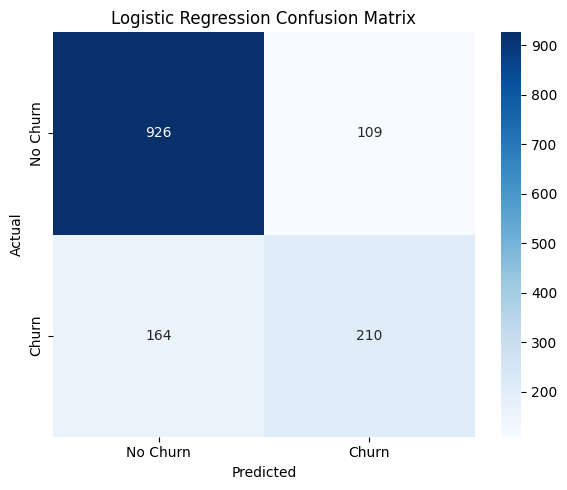

In [22]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [23]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 9. Random Forest Model

Random Forest is an ensemble learning algorithm that combines
multiple decision trees to produce a more robust prediction.

It can capture nonlinear relationships and interactions between
features that a linear model such as Logistic Regression may not
capture effectively.

Random Forest is evaluated using the same training and testing data
used for the baseline model.

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [26]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

In [27]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest pipeline trained successfully.")

Random Forest pipeline trained successfully.


In [28]:
rf_pred = random_forest_pipeline.predict(X_test)

rf_probability = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

In [29]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.7814
Precision: 0.61
Recall   : 0.4893
F1-score : 0.543
ROC-AUC  : 0.8236


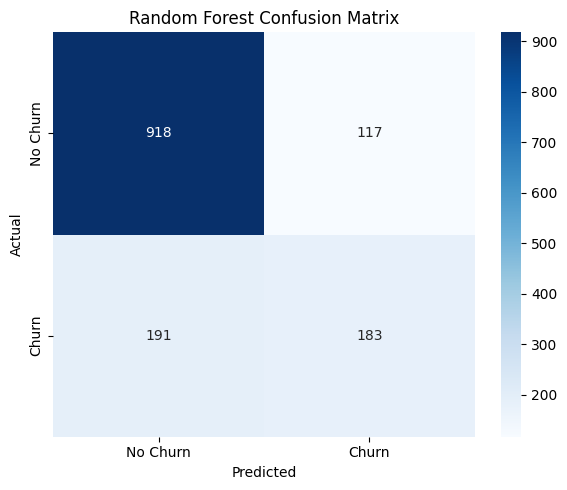

In [30]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## 10. XGBoost Model

XGBoost (Extreme Gradient Boosting) is a gradient-boosted decision
tree algorithm.

Unlike Random Forest, which builds many trees independently and
combines their predictions, gradient boosting builds trees
sequentially, with each new tree attempting to improve the errors
made by previous trees.

XGBoost is evaluated as a more advanced candidate model after
establishing simpler baselines.

In [31]:
import sys

print(sys.executable)
print(sys.version)

D:\Customer-Churn-Production-ML-Pipeline\.venv\Scripts\python.exe
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [32]:
import xgboost

print("XGBoost version:", xgboost.__version__)

from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost version: 3.2.0
XGBoost imported successfully.


In [33]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_probability = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_probability)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

XGBoost Results
----------------
Accuracy : 0.7921
Precision: 0.6346
Recall   : 0.5107
F1-score : 0.5659
ROC-AUC  : 0.838


In [34]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC_AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison = model_comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806246,0.658307,0.561497,0.606061,0.841918
2,XGBoost,0.792051,0.634551,0.510695,0.565926,0.838012
1,Random Forest,0.781405,0.610000,0.489305,0.543027,0.823569


In [35]:
model_comparison.to_csv(
    "../data/processed/model_comparison_baseline.csv",
    index=False
)

print("Baseline model comparison saved successfully.")

Baseline model comparison saved successfully.


## Class Imbalance Analysis

Before model tuning, we examine the distribution of the target variable.

The target variable `Churn` contains two classes:

- 0 → Customer did not churn
- 1 → Customer churned

Understanding the class distribution is important because an imbalanced target can cause a model to favor the majority class.

In [36]:
class_distribution = y.value_counts().sort_index()

print("Class Distribution")
print("-------------------")
print(class_distribution)

Class Distribution
-------------------
Churn
0    5174
1    1869
Name: count, dtype: int64


In [37]:
class_percentage = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Class Percentage")
print("----------------")
print(class_percentage.round(2))

Class Percentage
----------------
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [38]:
class_counts = y.value_counts()

majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count

print("Majority class count :", majority_count)
print("Minority class count :", minority_count)
print("Imbalance ratio      :", round(imbalance_ratio, 2))

Majority class count : 5174
Minority class count : 1869
Imbalance ratio      : 2.77


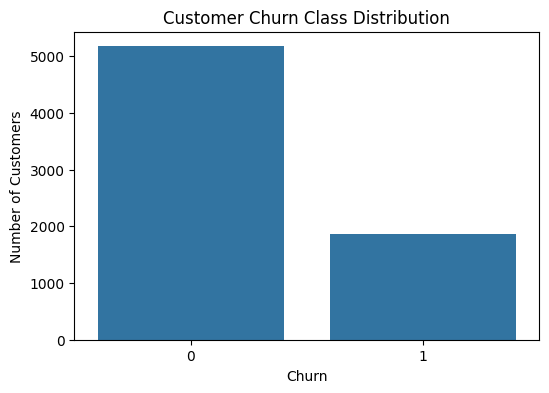

In [39]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y
)

plt.title("Customer Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Class-Weighted Logistic Regression

Class weighting is used to reduce the effect of class imbalance.

The `balanced` setting automatically assigns higher weight to the minority class based on the class frequencies in the training data.

In [40]:
weighted_logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

weighted_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", weighted_logistic_model)
    ]
)

weighted_logistic_pipeline.fit(X_train, y_train)

weighted_lr_pred = weighted_logistic_pipeline.predict(X_test)
weighted_lr_probability = (
    weighted_logistic_pipeline.predict_proba(X_test)[:, 1]
)

In [41]:
weighted_lr_accuracy = accuracy_score(
    y_test,
    weighted_lr_pred
)

weighted_lr_precision = precision_score(
    y_test,
    weighted_lr_pred
)

weighted_lr_recall = recall_score(
    y_test,
    weighted_lr_pred
)

weighted_lr_f1 = f1_score(
    y_test,
    weighted_lr_pred
)

weighted_lr_roc_auc = roc_auc_score(
    y_test,
    weighted_lr_probability
)

print("Class-Weighted Logistic Regression")
print("-----------------------------------")
print("Accuracy :", round(weighted_lr_accuracy, 4))
print("Precision:", round(weighted_lr_precision, 4))
print("Recall   :", round(weighted_lr_recall, 4))
print("F1-score :", round(weighted_lr_f1, 4))
print("ROC-AUC  :", round(weighted_lr_roc_auc, 4))

Class-Weighted Logistic Regression
-----------------------------------
Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7807
F1-score : 0.6128
ROC-AUC  : 0.8416


In [42]:
weighted_rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

weighted_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", weighted_rf_model)
    ]
)

weighted_rf_pipeline.fit(X_train, y_train)

weighted_rf_pred = weighted_rf_pipeline.predict(X_test)

weighted_rf_probability = (
    weighted_rf_pipeline.predict_proba(X_test)[:, 1]
)

In [43]:
weighted_rf_accuracy = accuracy_score(
    y_test,
    weighted_rf_pred
)

weighted_rf_precision = precision_score(
    y_test,
    weighted_rf_pred
)

weighted_rf_recall = recall_score(
    y_test,
    weighted_rf_pred
)

weighted_rf_f1 = f1_score(
    y_test,
    weighted_rf_pred
)

weighted_rf_roc_auc = roc_auc_score(
    y_test,
    weighted_rf_probability
)

print("Class-Weighted Random Forest")
print("----------------------------")
print("Accuracy :", round(weighted_rf_accuracy, 4))
print("Precision:", round(weighted_rf_precision, 4))
print("Recall   :", round(weighted_rf_recall, 4))
print("F1-score :", round(weighted_rf_f1, 4))
print("ROC-AUC  :", round(weighted_rf_roc_auc, 4))

Class-Weighted Random Forest
----------------------------
Accuracy : 0.7814
Precision: 0.6154
Recall   : 0.4706
F1-score : 0.5333
ROC-AUC  : 0.8242


In [44]:
class_weight_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest",
        "Weighted Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        weighted_lr_accuracy,
        rf_accuracy,
        weighted_rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        weighted_lr_precision,
        rf_precision,
        weighted_rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        weighted_lr_recall,
        rf_recall,
        weighted_rf_recall,
        xgb_recall
    ],
    "F1": [
        f1,
        weighted_lr_f1,
        rf_f1,
        weighted_rf_f1,
        xgb_f1
    ],
    "ROC_AUC": [
        roc_auc,
        weighted_lr_roc_auc,
        rf_roc_auc,
        weighted_rf_roc_auc,
        xgb_roc_auc
    ]
})

class_weight_comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806246,0.658307,0.561497,0.606061,0.841918
1,Weighted Logistic Regression,0.738112,0.504318,0.780749,0.612802,0.841572
4,XGBoost,0.792051,0.634551,0.510695,0.565926,0.838012
3,Weighted Random Forest,0.781405,0.615385,0.470588,0.533333,0.824239
2,Random Forest,0.781405,0.610000,0.489305,0.543027,0.823569


In [45]:
class_weight_comparison.to_csv(
    "../data/processed/class_weight_comparison.csv",
    index=False
)

print("Class-weight comparison saved successfully.")

Class-weight comparison saved successfully.


## XGBoost Class Imbalance Handling

XGBoost provides the `scale_pos_weight` parameter to adjust the importance of the positive class.

Because churn is represented by `1`, the parameter increases the relative importance of churn observations during model training.

The value is calculated using only the training data to avoid using information from the test set.

In [46]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class count:", negative_count)
print("Positive class count:", positive_count)
print("scale_pos_weight   :", round(scale_pos_weight, 4))

Negative class count: 4139
Positive class count: 1495
scale_pos_weight   : 2.7686


In [47]:
weighted_xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

weighted_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", weighted_xgb_model)
    ]
)

weighted_xgb_pipeline.fit(X_train, y_train)

weighted_xgb_pred = weighted_xgb_pipeline.predict(X_test)

weighted_xgb_probability = (
    weighted_xgb_pipeline.predict_proba(X_test)[:, 1]
)

In [48]:
weighted_xgb_accuracy = accuracy_score(
    y_test,
    weighted_xgb_pred
)

weighted_xgb_precision = precision_score(
    y_test,
    weighted_xgb_pred
)

weighted_xgb_recall = recall_score(
    y_test,
    weighted_xgb_pred
)

weighted_xgb_f1 = f1_score(
    y_test,
    weighted_xgb_pred
)

weighted_xgb_roc_auc = roc_auc_score(
    y_test,
    weighted_xgb_probability
)

print("Class-Weighted XGBoost Results")
print("--------------------------------")
print("Accuracy :", round(weighted_xgb_accuracy, 4))
print("Precision:", round(weighted_xgb_precision, 4))
print("Recall   :", round(weighted_xgb_recall, 4))
print("F1-score :", round(weighted_xgb_f1, 4))
print("ROC-AUC  :", round(weighted_xgb_roc_auc, 4))

Class-Weighted XGBoost Results
--------------------------------
Accuracy : 0.7537
Precision: 0.5258
Recall   : 0.7353
F1-score : 0.6132
ROC-AUC  : 0.8356


In [49]:
final_imbalance_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest",
        "Weighted Random Forest",
        "XGBoost",
        "Weighted XGBoost"
    ],
    "Accuracy": [
        accuracy,
        weighted_lr_accuracy,
        rf_accuracy,
        weighted_rf_accuracy,
        xgb_accuracy,
        weighted_xgb_accuracy
    ],
    "Precision": [
        precision,
        weighted_lr_precision,
        rf_precision,
        weighted_rf_precision,
        xgb_precision,
        weighted_xgb_precision
    ],
    "Recall": [
        recall,
        weighted_lr_recall,
        rf_recall,
        weighted_rf_recall,
        xgb_recall,
        weighted_xgb_recall
    ],
    "F1": [
        f1,
        weighted_lr_f1,
        rf_f1,
        weighted_rf_f1,
        xgb_f1,
        weighted_xgb_f1
    ],
    "ROC_AUC": [
        roc_auc,
        weighted_lr_roc_auc,
        rf_roc_auc,
        weighted_rf_roc_auc,
        xgb_roc_auc,
        weighted_xgb_roc_auc
    ]
})

final_imbalance_comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806246,0.658307,0.561497,0.606061,0.841918
1,Weighted Logistic Regression,0.738112,0.504318,0.780749,0.612802,0.841572
4,XGBoost,0.792051,0.634551,0.510695,0.565926,0.838012
5,Weighted XGBoost,0.753726,0.525813,0.735294,0.613155,0.835591
3,Weighted Random Forest,0.781405,0.615385,0.470588,0.533333,0.824239
2,Random Forest,0.781405,0.610000,0.489305,0.543027,0.823569


In [50]:
final_imbalance_comparison.to_csv(
    "../data/processed/imbalance_model_comparison.csv",
    index=False
)

print("Imbalance model comparison saved successfully.")

Imbalance model comparison saved successfully.


## Stratified Cross-Validation

Stratified K-Fold Cross-Validation is used to evaluate the model across multiple training and validation splits while preserving the approximate class distribution of the target variable in each fold.

This is particularly useful for classification problems with class imbalance.

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [52]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold Stratified Cross-Validation configured.")

5-fold Stratified Cross-Validation configured.


In [53]:
n_splits=5

In [54]:
xgb_cv_scores = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

In [55]:
xgb_cv_results = {
    "Accuracy": xgb_cv_scores["test_accuracy"].mean(),
    "Precision": xgb_cv_scores["test_precision"].mean(),
    "Recall": xgb_cv_scores["test_recall"].mean(),
    "F1": xgb_cv_scores["test_f1"].mean(),
    "ROC_AUC": xgb_cv_scores["test_roc_auc"].mean()
}

for metric, score in xgb_cv_results.items():
    print(f"{metric}: {score:.4f}")

Accuracy: 0.7982
Precision: 0.6504
Recall: 0.5177
F1: 0.5763
ROC_AUC: 0.8401


In [56]:
xgb_cv_results_df = pd.DataFrame(
    [xgb_cv_results]
)

xgb_cv_results_df.to_csv(
    "../data/processed/xgb_cross_validation_baseline.csv",
    index=False
)

print("XGBoost cross-validation results saved successfully.")

XGBoost cross-validation results saved successfully.


## XGBoost Hyperparameter Tuning

RandomizedSearchCV is used to search across multiple XGBoost hyperparameter combinations using Stratified Cross-Validation.

The optimization metric is ROC-AUC because the project is a binary classification problem with class imbalance.

The test set remains completely separate from the hyperparameter search.

In [57]:
from sklearn.model_selection import RandomizedSearchCV

In [58]:
xgb_param_grid = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

In [59]:
xgb_tuning_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [60]:
xgb_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_tuning_model)
    ]
)

In [61]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [62]:
xgb_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [63]:
print("Best Parameters:")
print("-----------------")

for parameter, value in xgb_random_search.best_params_.items():
    print(parameter, ":", value)

Best Parameters:
-----------------
model__subsample : 0.7
model__n_estimators : 300
model__min_child_weight : 3
model__max_depth : 5
model__learning_rate : 0.01
model__gamma : 0
model__colsample_bytree : 1.0


In [64]:
print("Best Cross-Validation ROC-AUC:")
print(round(xgb_random_search.best_score_, 4))

Best Cross-Validation ROC-AUC:
0.8492


In [65]:
xgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [66]:
print("Best XGBoost Parameters")
print("=======================")

for parameter, value in xgb_random_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest Cross-Validation ROC-AUC:")
print(round(xgb_random_search.best_score_, 4))

Best XGBoost Parameters
model__subsample: 0.7
model__n_estimators: 300
model__min_child_weight: 3
model__max_depth: 5
model__learning_rate: 0.01
model__gamma: 0
model__colsample_bytree: 1.0

Best Cross-Validation ROC-AUC:
0.8492


In [67]:
best_xgb_pipeline = xgb_random_search.best_estimator_

print("Best XGBoost pipeline retrieved successfully.")

Best XGBoost pipeline retrieved successfully.


In [68]:
best_xgb_pred = best_xgb_pipeline.predict(X_test)

best_xgb_probability = (
    best_xgb_pipeline.predict_proba(X_test)[:, 1]
)

In [69]:
best_xgb_accuracy = accuracy_score(
    y_test,
    best_xgb_pred
)

best_xgb_precision = precision_score(
    y_test,
    best_xgb_pred
)

best_xgb_recall = recall_score(
    y_test,
    best_xgb_pred
)

best_xgb_f1 = f1_score(
    y_test,
    best_xgb_pred
)

best_xgb_roc_auc = roc_auc_score(
    y_test,
    best_xgb_probability
)

print("Tuned XGBoost - Test Set Results")
print("================================")
print("Accuracy :", round(best_xgb_accuracy, 4))
print("Precision:", round(best_xgb_precision, 4))
print("Recall   :", round(best_xgb_recall, 4))
print("F1-score :", round(best_xgb_f1, 4))
print("ROC-AUC  :", round(best_xgb_roc_auc, 4))

Tuned XGBoost - Test Set Results
Accuracy : 0.7594
Precision: 0.5308
Recall   : 0.8075
F1-score : 0.6405
ROC-AUC  : 0.8478


## Tuned XGBoost Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for both churn and non-churn customers.

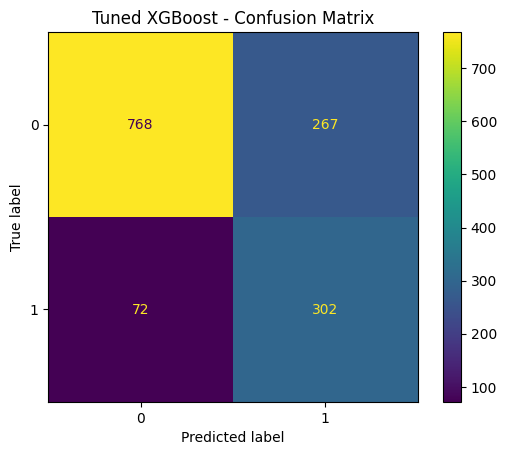

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_xgb_pred
)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

In [71]:
print("Tuned XGBoost Classification Report")
print("====================================")

print(
    classification_report(
        y_test,
        best_xgb_pred,
        target_names=["No Churn", "Churn"]
    )
)

Tuned XGBoost Classification Report
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.81      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [72]:
print("Minimum probability:", round(best_xgb_probability.min(), 4))
print("Maximum probability:", round(best_xgb_probability.max(), 4))

Minimum probability: 0.0363
Maximum probability: 0.9322


## Threshold Optimization

The default classification threshold is 0.50. We evaluate multiple thresholds to understand the trade-off between precision and recall.

The test-set probabilities are used here for final threshold analysis after model selection.

In [73]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        best_xgb_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1
0,0.20,0.385607,0.959893,0.550192
1,0.25,0.411215,0.941176,0.572358
2,0.30,0.437421,0.925134,0.593991
3,0.35,0.454047,0.885027,0.600181
4,0.40,0.476190,0.855615,0.611855
5,0.45,0.506536,0.828877,0.628803
6,0.50,0.530756,0.807487,0.640509
7,0.55,0.546875,0.748663,0.632054
8,0.60,0.576497,0.695187,0.630303
9,0.65,0.593350,0.620321,0.606536


In [74]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best threshold based on F1:", best_threshold)
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall   :", round(best_threshold_row["Recall"], 4))
print("F1-score :", round(best_threshold_row["F1"], 4))

Best threshold based on F1: 0.5
Precision: 0.5308
Recall   : 0.8075
F1-score : 0.6405


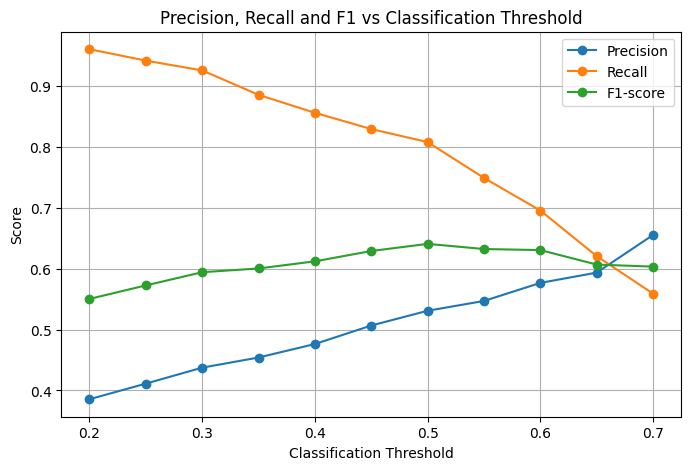

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Classification Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [76]:
optimized_xgb_pred = (
    best_xgb_probability >= best_threshold
).astype(int)

In [77]:
optimized_accuracy = accuracy_score(
    y_test,
    optimized_xgb_pred
)

optimized_precision = precision_score(
    y_test,
    optimized_xgb_pred,
    zero_division=0
)

optimized_recall = recall_score(
    y_test,
    optimized_xgb_pred,
    zero_division=0
)

optimized_f1 = f1_score(
    y_test,
    optimized_xgb_pred,
    zero_division=0
)

print("Optimized XGBoost Threshold Results")
print("===================================")
print("Threshold :", best_threshold)
print("Accuracy  :", round(optimized_accuracy, 4))
print("Precision :", round(optimized_precision, 4))
print("Recall    :", round(optimized_recall, 4))
print("F1-score  :", round(optimized_f1, 4))
print("ROC-AUC   :", round(best_xgb_roc_auc, 4))

Optimized XGBoost Threshold Results
Threshold : 0.5
Accuracy  : 0.7594
Precision : 0.5308
Recall    : 0.8075
F1-score  : 0.6405
ROC-AUC   : 0.8478


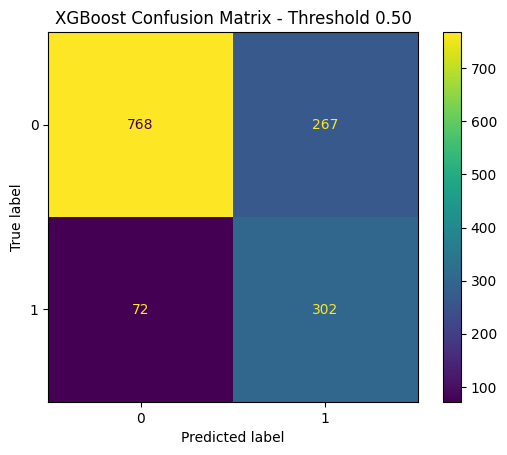

In [78]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_xgb_pred
)

plt.title(
    f"XGBoost Confusion Matrix - Threshold {best_threshold:.2f}"
)

plt.show()

## Final Model Evaluation

The tuned XGBoost model is compared with the baseline XGBoost model.

The final evaluation considers accuracy, precision, recall, F1-score and ROC-AUC. Threshold optimization is also considered because the default 0.50 threshold may not provide the desired balance between precision and recall.

In [79]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        xgb_accuracy,
        best_xgb_accuracy
    ],
    "Precision": [
        xgb_precision,
        best_xgb_precision
    ],
    "Recall": [
        xgb_recall,
        best_xgb_recall
    ],
    "F1": [
        xgb_f1,
        best_xgb_f1
    ],
    "ROC_AUC": [
        xgb_roc_auc,
        best_xgb_roc_auc
    ]
})

final_model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline XGBoost,0.792051,0.634551,0.510695,0.565926,0.838012
1,Tuned XGBoost,0.759404,0.530756,0.807487,0.640509,0.847829


In [80]:
final_model_comparison.to_csv(
    "../data/processed/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.


## ROC Curve

The ROC curve evaluates the model's ability to distinguish between churn and non-churn customers across different classification thresholds.

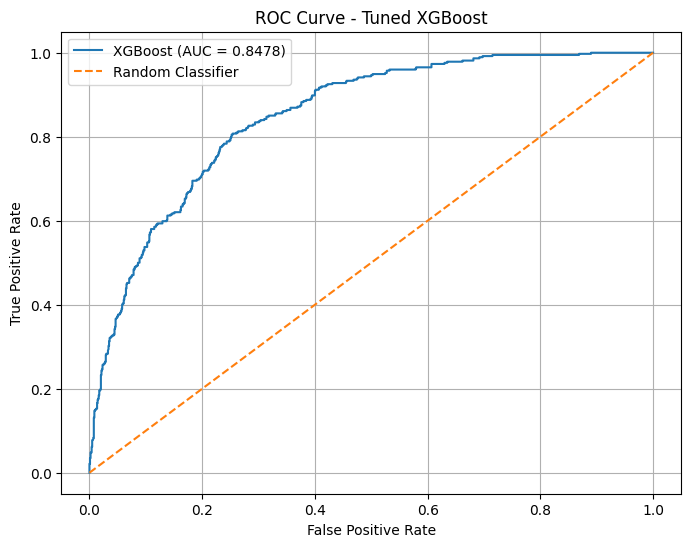

In [81]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    best_xgb_probability
)

roc_auc_value = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc_value:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend()
plt.grid(True)

plt.show()

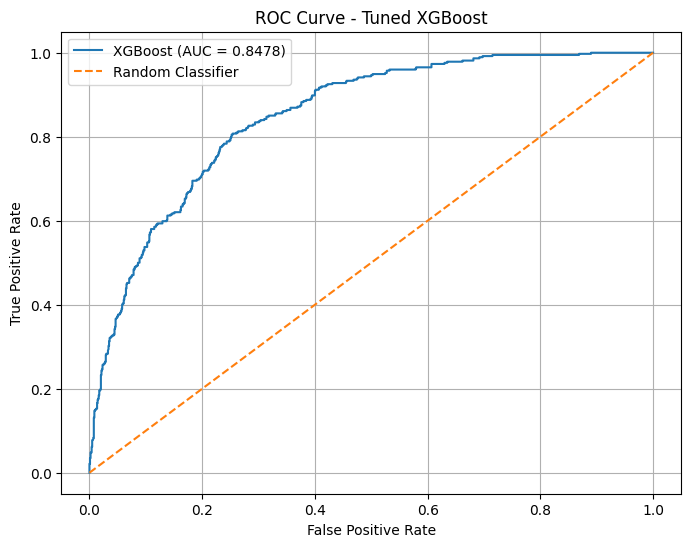

In [82]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    best_xgb_probability
)

roc_auc_value = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc_value:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend()
plt.grid(True)

plt.show()

In [83]:
final_predictions = (
    best_xgb_probability >= best_threshold
).astype(int)

In [84]:
final_confusion_matrix = confusion_matrix(
    y_test,
    final_predictions
)

print("Final Confusion Matrix")
print("======================")
print(final_confusion_matrix)

Final Confusion Matrix
[[768 267]
 [ 72 302]]


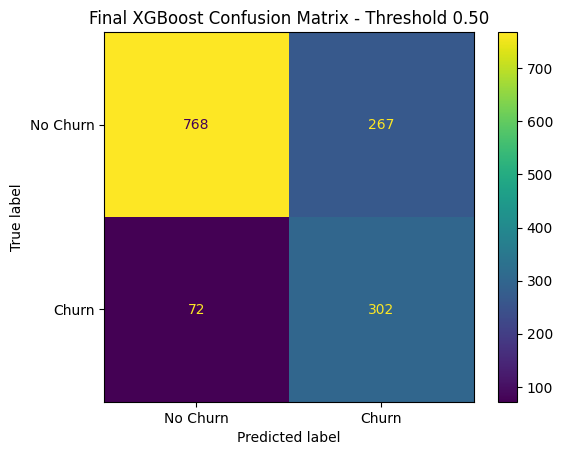

In [85]:
ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title(
    f"Final XGBoost Confusion Matrix - Threshold {best_threshold:.2f}"
)

plt.show()

In [86]:
import joblib

In [87]:
joblib.dump(
    best_xgb_pipeline,
    "../models/final_xgboost_pipeline.pkl"
)

print("Final XGBoost pipeline saved successfully.")

Final XGBoost pipeline saved successfully.


In [88]:
joblib.dump(
    best_threshold,
    "../models/churn_threshold.pkl"
)

print("Churn threshold saved successfully.")

Churn threshold saved successfully.


In [89]:
import json

In [90]:
model_metadata = {
    "model_type": "XGBoost",
    "threshold": float(best_threshold),
    "cv_roc_auc": float(xgb_random_search.best_score_),
    "test_accuracy": float(best_xgb_accuracy),
    "test_precision": float(best_xgb_precision),
    "test_recall": float(best_xgb_recall),
    "test_f1": float(best_xgb_f1),
    "test_roc_auc": float(best_xgb_roc_auc)
}

with open(
    "../models/model_metadata.json",
    "w"
) as file:
    json.dump(
        model_metadata,
        file,
        indent=4
    )

print("Model metadata saved successfully.")

Model metadata saved successfully.
